# AI & ML Internship — Task 10
## KNN: Handwritten Digit Classification

### Objective:
- Classify handwritten digits using K-Nearest Neighbors
- Understand distance-based classification
- Apply feature scaling for fair distance computation
- Tune K to find optimal model performance
- Visualize predictions and misclassifications


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [3]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset loaded successfully")
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Dataset loaded successfully
Feature matrix shape: (1797, 64)
Target shape: (1797,)


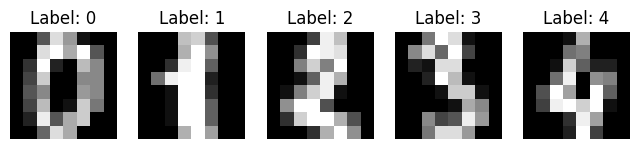

In [4]:
plt.figure(figsize=(8,3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.show()


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)


Training size: (1437, 64)
Testing size : (360, 64)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy with K=3:", accuracy)


Accuracy with K=3: 0.9666666666666667


In [8]:
k_values = [3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

for k, acc in zip(k_values, accuracies):
    print(f"K={k} → Accuracy={acc:.4f}")


K=3 → Accuracy=0.9667
K=5 → Accuracy=0.9639
K=7 → Accuracy=0.9667
K=9 → Accuracy=0.9639


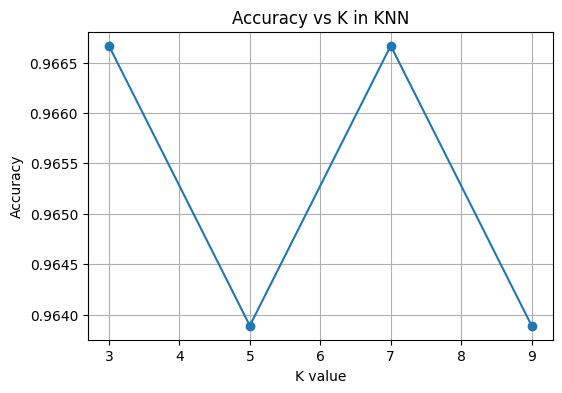

In [9]:
plt.figure(figsize=(6,4))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K in KNN")
plt.grid(True)

plt.savefig("accuracy_vs_k.png", dpi=300, bbox_inches="tight")
plt.show()


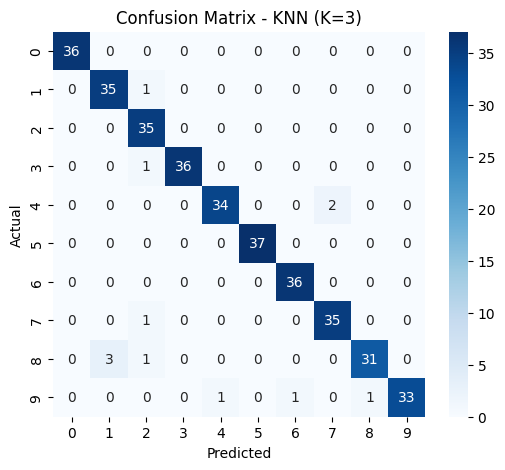

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN (K=3)")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


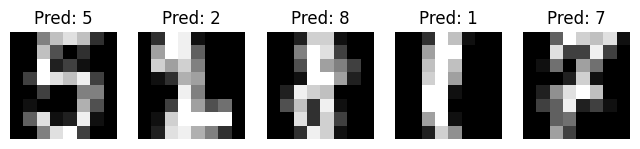

In [11]:
plt.figure(figsize=(8,3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap="gray")
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis("off")
plt.show()
